In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random

In [2]:
df = pd.read_csv('news_dataset.csv')
isot = pd.read_csv('True.csv')
isot_f = pd.read_csv("Fake.csv")
isot = isot.dropna()
isot_f = isot_f.dropna()
df = df.dropna()
print(df.isnull().sum())
print(isot.isnull().sum())
print(isot_f.isnull().sum())

label    0
text     0
dtype: int64
title      0
text       0
subject    0
date       0
dtype: int64
title      0
text       0
subject    0
date       0
dtype: int64


In [3]:
df

,label,text
0,REAL,Payal has accused filmmaker Anurag Kashyap of ...
1,FAKE,A four-minute-long video of a woman criticisin...
2,FAKE,"Republic Poll, a fake Twitter account imitatin..."
3,REAL,"Delhi teen finds place on UN green list, turns..."
4,REAL,Delhi: A high-level meeting underway at reside...
...,...,...
3724,REAL,19:17 (IST) Sep 20\n\nThe second round of coun...
3725,REAL,19:17 (IST) Sep 20\n\nThe second round of coun...
3726,FAKE,The Bengaluru City Police’s official Twitter h...
3727,REAL,"Sep 20, 2020, 08:00AM IST\n\nSource: TOI.in\n\..."


In [4]:
isot

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


In [5]:
isot_f

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [6]:
df = df.drop_duplicates(subset=['text'])
isot = isot.drop_duplicates(subset=['text'])
isot_f = isot_f.drop_duplicates(subset=['text'])
df.shape, isot.shape, isot_f.shape

((2229, 2), (21192, 4), (17455, 4))

In [7]:
def plot_sequence_word_counts(sequences):
    word_counts = [len(sequence.split()) for sequence in sequences]

    min_length_index = word_counts.index(min(word_counts))
    max_length_index = word_counts.index(max(word_counts))

    print("Sequence with minimum length:", len(sequences[min_length_index]), " - index: ", min_length_index)
    print("Sequence with maximum length:", len(sequences[max_length_index]), " - index: ", max_length_index)
    print("Sequence average length: ", sum(word_counts)/len(sequences))

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    sns.histplot(word_counts, bins=40, kde=True, color="skyblue")
    
    plt.xlabel("Word Count")
    plt.ylabel("Frequency")
    plt.title("Histogram of Word Counts for Sequences")
    plt.show()

def clean_text(sequence):
    seq = []
    for text in sequence:
        text = re.sub(r'^[A-Z]+\s+\([^\)]+\)\s*\-.', '', text)
        text = re.sub(r'\bbit\.ly\S*.*$', '', text)
        text = re.sub(r'<[^>]*?>', '', text)
        text = re.sub(r'http[s]?://\S+', '', text)
        text = re.sub(r'[^a-zA-Z0-9. ]', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'^.*- ?', ' ', text)
        text = text.strip()
        seq.append(text)
    return seq

Sequence with minimum length: 2535  - index:  938
Sequence with maximum length: 2373  - index:  97
Sequence average length:  460.9802602063706


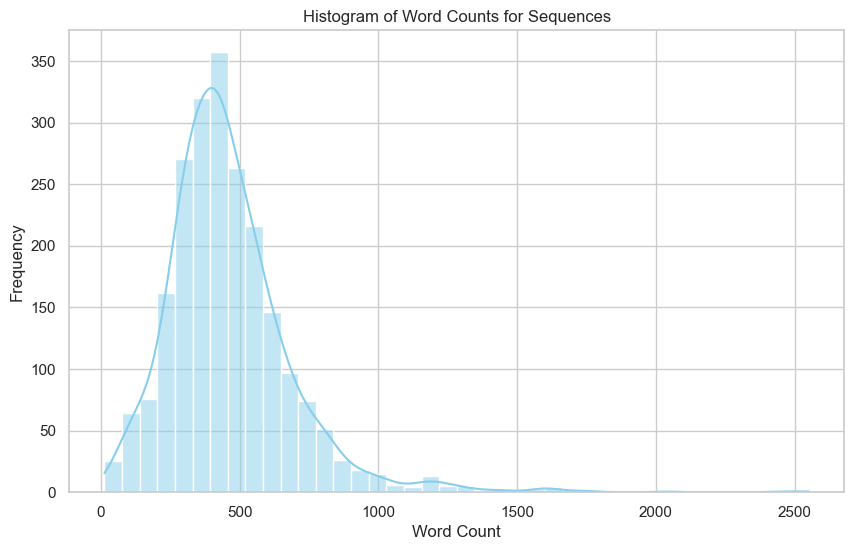

C:\Users\asus\AppData\Local\Temp\ipykernel_7908\4081289420.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'] = clean_text(df['text'])


Sequence with minimum length: 1804  - index:  8920
Sequence with maximum length: 1865  - index:  2802
Sequence average length:  384.81275953189885


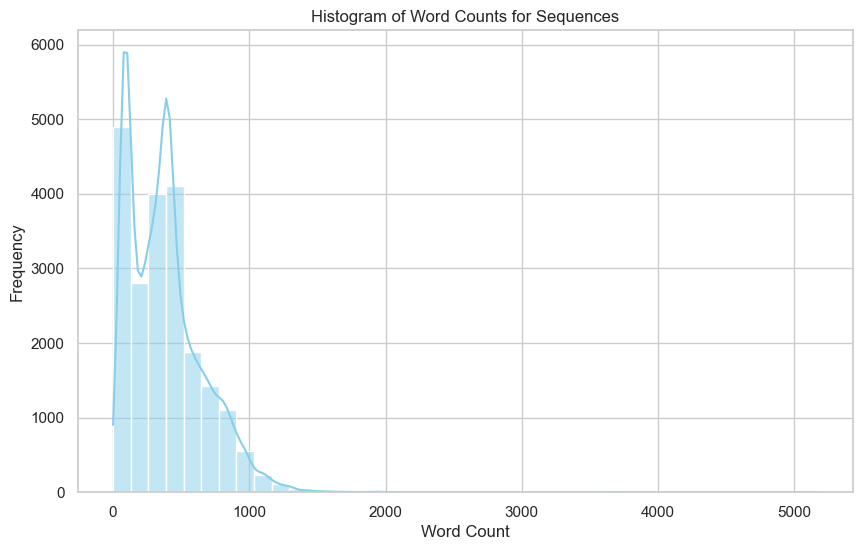

C:\Users\asus\AppData\Local\Temp\ipykernel_7908\4081289420.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isot['text'] = clean_text(isot['text'])


Sequence with minimum length: 12567  - index:  10920
Sequence with maximum length: 876  - index:  17055
Sequence average length:  425.25711830421085


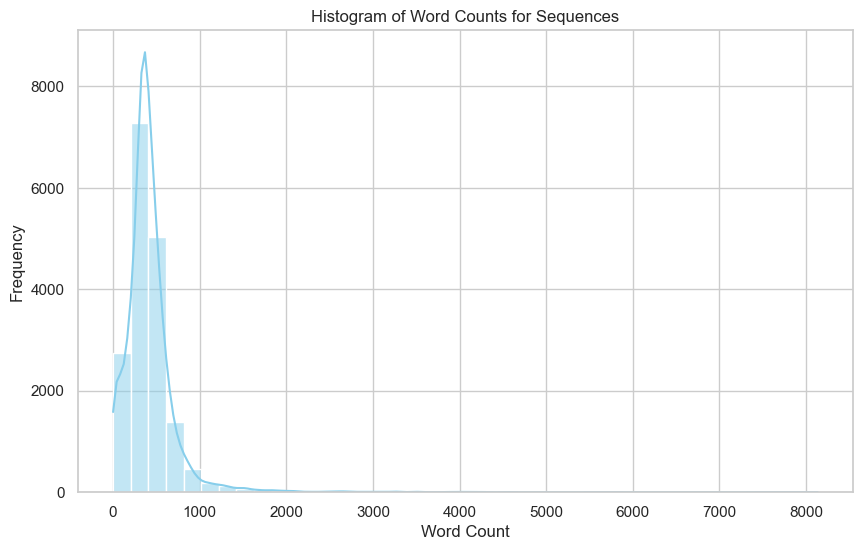

C:\Users\asus\AppData\Local\Temp\ipykernel_7908\4081289420.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isot_f['text'] = clean_text(isot_f['text'])


In [8]:
plot_sequence_word_counts(df['text'])
df['text'] = clean_text(df['text'])
plot_sequence_word_counts(isot['text'])
isot['text'] = clean_text(isot['text'])
plot_sequence_word_counts(isot_f['text'])
isot_f['text'] = clean_text(isot_f['text'])

In [9]:
isot = isot[isot['text'].str.len() <= 1200]
df = df[df['text'].str.len() <= 1200]
isot_f = isot_f[isot_f['text'].str.len() <= 1200]

In [10]:
df

,label,text
0,REAL,Payal has accused filmmaker Anurag Kashyap of ...
10,REAL,Ahmedabad Crime branch sleuths on Friday held ...
18,REAL,Kareena Kapoor Khan who is all set to ring in ...
28,FAKE,Watch episode 5 Of Fact Vs Fiction where Suyas...
30,REAL,20 34 IST Sep 20 We don t understand why this ...
...,...,...
3631,REAL,KOLKATA West Bengal CM Mamata Banerjee has pos...
3661,FAKE,Claim This is the tarmac at Mumbai s Chhatrapa...
3671,REAL,Superstar Priyanka Chopra Jonas has now been l...
3676,REAL,PANAJI The second phase of reviving the coconu...


In [11]:
isot

,title,text,subject,date
7,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
8,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
9,Alabama official to certify Senator-elect Jone...,Alabama Secretary of State John Merrill said h...,politicsNews,"December 28, 2017"
12,Factbox: Trump on Twitter (Dec 28) - Vanity Fa...,The following statements were posted to the ve...,politicsNews,"December 28, 2017"
13,"Trump on Twitter (Dec 27) - Trump, Iraq, Syria",The following statements were posted to the ve...,politicsNews,"December 28, 2017"
...,...,...,...,...
21362,Poland will not change its stance on EU's post...,Poland will not change its stance on the Europ...,worldnews,"August 24, 2017"
21370,Finnish police release one knife attack suspect,Finnish police on Thursday released one of six...,worldnews,"August 24, 2017"
21399,Saudi police release teenager detained for dan...,A 14 year old boy who was detained by Saudi po...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,LexisNexis a provider of legal regulatory and ...,worldnews,"August 22, 2017"


In [12]:
isot_f

,title,text,subject,date
84,Trump Just Got His P*ssy Handed To Him By New...,Donald Trump bit off a bit more than he could ...,News,"November 17, 2017"
108,Sean Hannity Just Said Child Molestation Is O...,Republicans for some reason think it s perfect...,News,"November 9, 2017"
184,Trump Just Got Banned From The Place Where He...,You know how a lot of couples celebrate annive...,News,"October 26, 2017"
307,One Republican Senator Is So Fed Up With Trum...,Donald Trump has been a thorn in Senator Bob C...,News,"September 26, 2017"
627,Donald Trump Is Acting Just Like Kim Jong: Th...,Donald Trump is going to get us in a war and b...,News,"August 8, 2017"
...,...,...,...,...
22672,"BOILER ROOM – Examination, Exclamation, Excita...",Tune in to the Alternate Current Radio Network...,US_News,"February 3, 2016"
22674,Activist: ‘This is where you can make the most...,21st Century Wire says If you ve been followin...,US_News,"February 3, 2016"
22685,Ron Paul on Burns Oregon Standoff and Jury Nul...,21st Century Wire says If you ve been followin...,US_News,"January 21, 2016"
22686,BOILER ROOM: As the Frogs Slowly Boil – EP #40,Tune in to the Alternate Current Radio Network...,US_News,"January 20, 2016"


In [13]:
# training data
train1 = df[df['label'] == 'REAL']
train1

,label,text
0,REAL,Payal has accused filmmaker Anurag Kashyap of ...
10,REAL,Ahmedabad Crime branch sleuths on Friday held ...
18,REAL,Kareena Kapoor Khan who is all set to ring in ...
30,REAL,20 34 IST Sep 20 We don t understand why this ...
38,REAL,NEW DELHI Prime Minister Narendra Modi is like...
...,...,...
3547,REAL,KAUSHAMBI Three teenage girls drowned while th...
3631,REAL,KOLKATA West Bengal CM Mamata Banerjee has pos...
3671,REAL,Superstar Priyanka Chopra Jonas has now been l...
3676,REAL,PANAJI The second phase of reviving the coconu...


In [14]:
train2 = isot[:403]
train2['label'] = "REAL"
train2 = train2[['text', 'label']]
train2


C:\Users\asus\AppData\Local\Temp\ipykernel_7908\920726007.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['label'] = "REAL"


,text,label
7,The following statements were posted to the ve...,REAL
8,The following statements were posted to the ve...,REAL
9,Alabama Secretary of State John Merrill said h...,REAL
12,The following statements were posted to the ve...,REAL
13,The following statements were posted to the ve...,REAL
...,...,...
1265,U.S. President Donald Trump struck a blow agai...,REAL
1269,Mexican Finance Minister Jose Antonio Meade sa...,REAL
1270,Representatives of Facebook Twitter and Google...,REAL
1272,U.S. Treasury Secretary Steven Mnuchin said on...,REAL


In [15]:
train = pd.concat([train1, train2])

In [16]:
train = train.sample(frac=1, random_state=42)

In [17]:
test1 = df[df['label'] == 'FAKE']
test1 = test1.sample(frac=1)
test1

,label,text
2779,FAKE,A viral notice purporting to show that the las...
1522,FAKE,Claim A Politcian can fight Elections from two...
3505,FAKE,Claim 20 churches were burnt down last night a...
2761,FAKE,An image of a woman holding a child at a cance...
2221,FAKE,Claim This is the accused Mohammed Illias who ...
...,...,...
705,FAKE,Claim Karnataka Congress workers were trying t...
344,FAKE,Watch episode 3 Of Fact Vs Fiction where Suyas...
1413,FAKE,Who is the man behind the Facebook page Hindut...
1489,FAKE,A viral message falsely claiming that Electron...


In [18]:
test2 = isot[:186]
test2['label'] = "FAKE"
test2 = test2[['label', 'text']]
test2

C:\Users\asus\AppData\Local\Temp\ipykernel_7908\554919040.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test2['label'] = "FAKE"


,label,text
7,FAKE,The following statements were posted to the ve...
8,FAKE,The following statements were posted to the ve...
9,FAKE,Alabama Secretary of State John Merrill said h...
12,FAKE,The following statements were posted to the ve...
13,FAKE,The following statements were posted to the ve...
...,...,...
536,FAKE,The deputy director of the U.S. Consumer Finan...
538,FAKE,The White House may name an acting director of...
541,FAKE,U.S. President Donald Trump has designated Whi...
543,FAKE,U.S. President Donald Trump will meet with Sen...


In [19]:
test3 = isot[122:372]
test3['label'] = "REAL"
test3 = test3[['label', 'text']]
test3

C:\Users\asus\AppData\Local\Temp\ipykernel_7908\924998049.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test3['label'] = "REAL"


,label,text
402,REAL,Republican U.S. Senator Steve Daines of Montan...
403,REAL,The No. 2 U.S. Senate Republican John Cornyn s...
404,REAL,U.S. Senate Republican leader Mitch McConnell ...
406,REAL,The United States remains committed to the Lib...
407,REAL,Former U.S. national security adviser Michael ...
...,...,...
1184,REAL,Greek Prime Minister Alexis Tsipras said on Tu...
1191,REAL,U.S. President Donald Trump is leaning toward ...
1194,REAL,An Oct. 24 hearing in the U.S. Congress on Pue...
1196,REAL,Republican U.S. Senator Thad Cochran said he h...


In [20]:
test = pd.concat([test1, test2, test3])
test.shape

(500, 2)

In [21]:
test

,label,text
2779,FAKE,A viral notice purporting to show that the las...
1522,FAKE,Claim A Politcian can fight Elections from two...
3505,FAKE,Claim 20 churches were burnt down last night a...
2761,FAKE,An image of a woman holding a child at a cance...
2221,FAKE,Claim This is the accused Mohammed Illias who ...
...,...,...
1184,REAL,Greek Prime Minister Alexis Tsipras said on Tu...
1191,REAL,U.S. President Donald Trump is leaning toward ...
1194,REAL,An Oct. 24 hearing in the U.S. Congress on Pue...
1196,REAL,Republican U.S. Senator Thad Cochran said he h...


In [22]:
test=test.sample(frac=1, random_state=42)

In [23]:
train.to_csv('train_data.csv', index=False)
test.to_csv('test_data.csv', index=False)

In [24]:
df =  pd.read_csv('train_data.csv')
df

,label,text
0,REAL,The U.S. Senate on Monday voted to confirm Pre...
1,REAL,U.S. President Donald Trump met on Thursday wi...
2,REAL,U.S. President Donald Trump is leaning toward ...
3,REAL,Senate Democratic leader Chuck Schumer said on...
4,REAL,Please note that the story USA TAX STUDY headl...
...,...,...
505,REAL,Sep 20 2020 08 00AM IST Source TOI.in Meet Nee...
506,REAL,U.S. President Donald Trump is slated to give ...
507,REAL,U.S. Secretary of State Rex Tillerson said on ...
508,REAL,Republican leaders of two committees in the U....


In [25]:
df =  pd.read_csv('test_data.csv')
df

,label,text
0,REAL,The National Federation of Independent Busines...
1,FAKE,Legislation to provide 81 billion in new disas...
2,REAL,U.S. President Donald Trump told Chinese Presi...
3,FAKE,The U.S. Congress may be able to wrap up tax n...
4,FAKE,House Speaker Paul Ryan has told President Don...
...,...,...
495,FAKE,U.S. Republican Senator Mike Lee has not decid...
496,REAL,British Prime Minister Theresa May said on Thu...
497,REAL,U.S. President Donald Trump arrived in the Phi...
498,REAL,U.S. President Donald Trump s former campaign ...


In [26]:
df.label.info()

<class 'pandas.core.series.Series'>
RangeIndex: 500 entries, 0 to 499
Series name: label
Non-Null Count  Dtype 
--------------  ----- 
500 non-null    object
dtypes: object(1)
memory usage: 4.0+ KB
